<a href="https://colab.research.google.com/github/Mohamed-47/Sleep-Lifestyle-Study-ML-EDA-/blob/main/sleep_health_ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep Health & Lifestyle Study — EDA & Predictive Modeling
**Course:** Machine Learning | **Part 2:** Exploratory Data Analysis + Model Fitting

**Dataset:** [Sleep and Lifestyle Study – Kaggle](https://www.kaggle.com/datasets/ayeshaimran1619/sleep-and-lifestyle-study)

---
### Research Questions (from Part 1 Proposal)
1. Can we predict whether a person has a sleep disorder (None / Insomnia / Sleep Apnea) from lifestyle & health data?
2. Does higher stress *always* mean worse sleep quality, and does this hold across all groups?
3. Does a person's occupation affect how likely they are to have a sleep disorder?


## 0. Setup — Install Dependencies & Import Libraries

In [3]:
# ── Install kagglehub if needed ──────────────────────────────────────────────
# Run once; comment out after first successful download
#!pip install kagglehub

# ── Standard imports ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import os, glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from xgboost import XGBClassifier

# Consistent plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
plt.rcParams["figure.dpi"] = 110
print("All libraries imported successfully.")


All libraries imported successfully.


## 1. Load the Dataset

In [4]:
# ── Download dataset from Kaggle ─────────────────────────────────────────────
path = kagglehub.dataset_download("ayeshaimran1619/sleep-and-lifestyle-study")
print("Downloaded to:", path)

# ── Find the CSV file ─────────────────────────────────────────────────────────
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print("CSV files found:", csv_files)

df_raw = pd.read_csv(csv_files[0])
print(f"\nShape: {df_raw.shape}")
df_raw.head()


100%|██████████| 2.54k/2.54k [00:00<00:00, 4.61MB/s]

Extracting files...
Downloaded to: /root/.cache/kagglehub/datasets/ayeshaimran1619/sleep-and-lifestyle-study/versions/1
CSV files found: ['/root/.cache/kagglehub/datasets/ayeshaimran1619/sleep-and-lifestyle-study/versions/1/Sleep_health_and_lifestyle_dataset.csv']

Shape: (374, 13)


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## 2. Data Cleaning & Preprocessing

In [5]:
df = df_raw.copy()

# ── Standardise column names ──────────────────────────────────────────────────
df.columns = df.columns.str.strip().str.title().str.replace(" ", "_")
print("Columns:", df.columns.tolist())

# ── Handle Sleep Disorder NaN → 'None' ───────────────────────────────────────
# NaN in this column means no disorder was reported
target_col = [c for c in df.columns if "Disorder" in c][0]
df[target_col] = df[target_col].fillna("None")

# ── Standardise BMI label (Normal vs Normal Weight) ───────────────────────────
bmi_col = [c for c in df.columns if "Bmi" in c or "BMI" in c][0]
df[bmi_col] = df[bmi_col].replace("Normal Weight", "Normal")

# ── Split Blood Pressure into Systolic / Diastolic ───────────────────────────
bp_col = [c for c in df.columns if "Pressure" in c][0]
if df[bp_col].dtype == object:
    df[["Systolic_BP", "Diastolic_BP"]] = (
        df[bp_col].str.split("/", expand=True).astype(float)
    )
    df.drop(columns=[bp_col], inplace=True)

# ── Drop Person ID if present ─────────────────────────────────────────────────
id_cols = [c for c in df.columns if "Id" in c or "Person" in c]
df.drop(columns=id_cols, inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())
print("\nTarget distribution:")
print(df[target_col].value_counts())


Columns: ['Person_Id', 'Gender', 'Age', 'Occupation', 'Sleep_Duration', 'Quality_Of_Sleep', 'Physical_Activity_Level', 'Stress_Level', 'Bmi_Category', 'Blood_Pressure', 'Heart_Rate', 'Daily_Steps', 'Sleep_Disorder']

Missing values after cleaning:
Gender                     0
Age                        0
Occupation                 0
Sleep_Duration             0
Quality_Of_Sleep           0
Physical_Activity_Level    0
Stress_Level               0
Bmi_Category               0
Heart_Rate                 0
Daily_Steps                0
Sleep_Disorder             0
Systolic_BP                0
Diastolic_BP               0
dtype: int64

Target distribution:
Sleep_Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


In [6]:
# ── Summary statistics ────────────────────────────────────────────────────────
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Gender,374,2,Male,189,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,374.0,NaN,NaN,NaN,42.184492,8.673133,27.0,35.25,43.0,50.0,59.0
Occupation,374,11,Nurse,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Duration,374.0,NaN,NaN,NaN,7.132086,0.795657,5.8,6.4,7.2,7.8,8.5
Quality_Of_Sleep,374.0,NaN,NaN,NaN,7.312834,1.196956,4.0,6.0,7.0,8.0,9.0
Physical_Activity_Level,374.0,NaN,NaN,NaN,59.171123,20.830804,30.0,45.0,60.0,75.0,90.0
Stress_Level,374.0,NaN,NaN,NaN,5.385027,1.774526,3.0,4.0,5.0,7.0,8.0
Bmi_Category,374,3,Normal,216,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Heart_Rate,374.0,NaN,NaN,NaN,70.165775,4.135676,65.0,68.0,70.0,72.0,86.0
Daily_Steps,374.0,NaN,NaN,NaN,6816.84492,1617.915679,3000.0,5600.0,7000.0,8000.0,10000.0


## 3. Exploratory Data Analysis

We will explore:
- The distribution of the **target variable** (Sleep Disorder)
- Distributions of key numeric features
- Relationships between **Stress Level** and **Sleep Quality**
- How **Occupation** relates to sleep disorders
- A **correlation heatmap** of all numeric features
- Feature distributions split by sleep disorder class


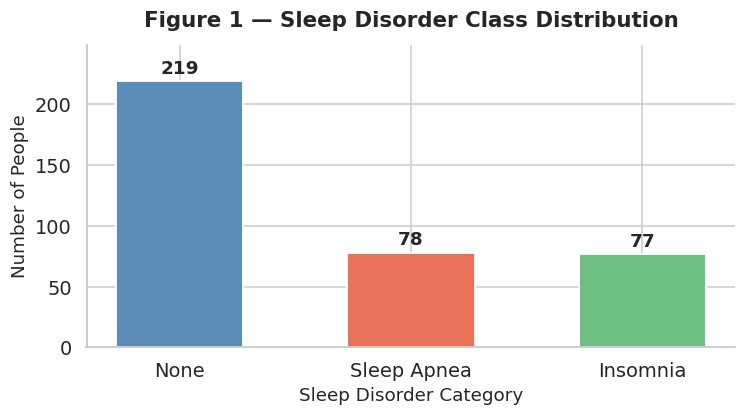


Class proportions:
Sleep_Disorder
None           58.6%
Sleep Apnea    20.9%
Insomnia       20.6%
Name: count, dtype: object


In [7]:
# ── Figure 1: Target Class Distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
order = df[target_col].value_counts().index
counts = df[target_col].value_counts()
colors = ["#5B8DB8", "#E8735A", "#6DBF82"]

bars = ax.bar(order, counts[order], color=colors, edgecolor="white", linewidth=1.2, width=0.55)
for bar, count in zip(bars, counts[order]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(count), ha="center", va="bottom", fontweight="bold", fontsize=12)

ax.set_title("Figure 1 — Sleep Disorder Class Distribution", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Sleep Disorder Category", fontsize=12)
ax.set_ylabel("Number of People", fontsize=12)
ax.set_ylim(0, counts.max() + 30)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig1_target_distribution.png", bbox_inches="tight")
plt.show()
print(f"\nClass proportions:\n{(counts/len(df)*100).round(1).astype(str) + '%'}")


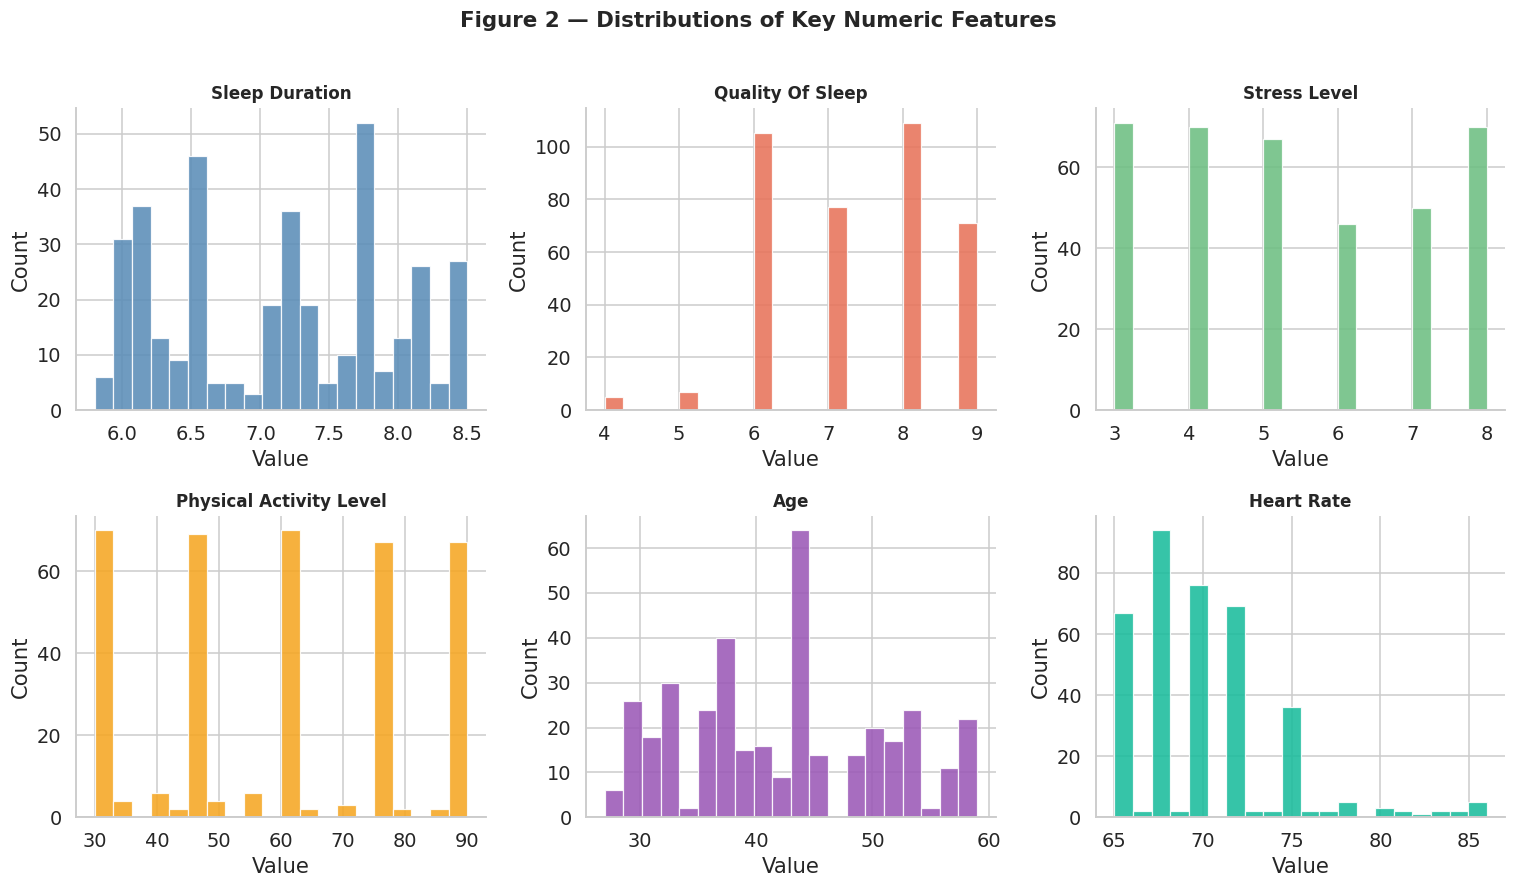

In [8]:
# ── Figure 2: Distributions of Key Numeric Features ──────────────────────────
num_cols = ["Sleep_Duration", "Quality_Of_Sleep", "Stress_Level",
            "Physical_Activity_Level", "Age", "Heart_Rate"]
# Fallback: pick numeric cols that exist
num_cols = [c for c in num_cols if c in df.columns]
if not num_cols:
    num_cols = df.select_dtypes(include=np.number).columns.tolist()[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
palette = ["#5B8DB8", "#E8735A", "#6DBF82", "#F5A623", "#9B59B6", "#1ABC9C"]

for i, col in enumerate(num_cols[:6]):
    axes[i].hist(df[col].dropna(), bins=20, color=palette[i], edgecolor="white",
                 linewidth=0.8, alpha=0.88)
    axes[i].set_title(col.replace("_", " "), fontsize=11, fontweight="bold")
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    axes[i].spines[["top", "right"]].set_visible(False)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Figure 2 — Distributions of Key Numeric Features",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig2_numeric_distributions.png", bbox_inches="tight")
plt.show()


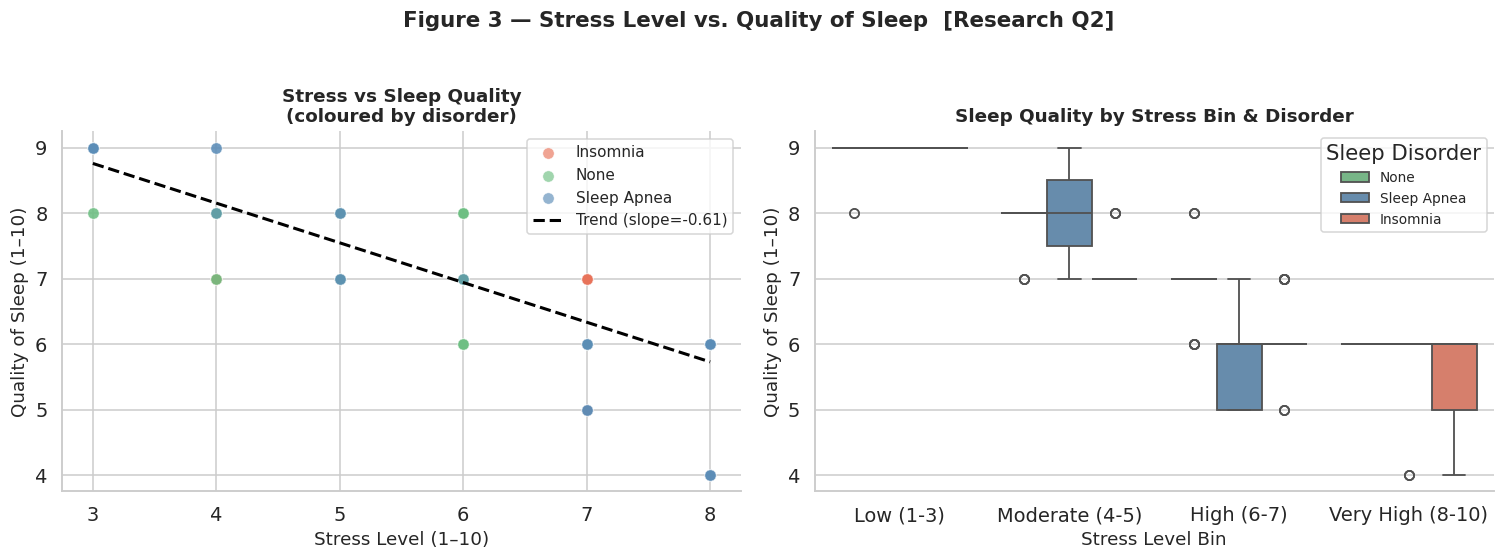

Pearson r = -0.899,  p-value = 2.88e-135
Regression slope: -0.606  (for every +1 stress point, quality drops ~0.61 points)


In [10]:
# ── Figure 3: Stress Level vs. Quality of Sleep ───────────────────────────────
# Directly addresses Research Question 2

stress_col = [c for c in df.columns if "Stress" in c][0]
quality_col = [c for c in df.columns if "Quality" in c][0]

palette_disorder = {"None": "#6DBF82", "Insomnia": "#E8735A", "Sleep Apnea": "#5B8DB8"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter coloured by disorder
for disorder, grp in df.groupby(target_col):
    axes[0].scatter(grp[stress_col], grp[quality_col],
                    label=disorder, alpha=0.65, s=55,
                    color=palette_disorder.get(disorder, "grey"), edgecolors="white", linewidth=0.4)

# Regression line (all data)
m, b = np.polyfit(df[stress_col], df[quality_col], 1)
x_line = np.linspace(df[stress_col].min(), df[stress_col].max(), 100)
axes[0].plot(x_line, m*x_line + b, color="black", linewidth=2, linestyle="--", label=f"Trend (slope={m:.2f})")
axes[0].set_xlabel("Stress Level (1–10)", fontsize=12)
axes[0].set_ylabel("Quality of Sleep (1–10)", fontsize=12)
axes[0].set_title("Stress vs Sleep Quality\n(coloured by disorder)", fontsize=12, fontweight="bold")
axes[0].legend(fontsize=10)
axes[0].spines[["top", "right"]].set_visible(False)

# Right: box plots of quality per stress bin × disorder
df["Stress_Bin"] = pd.cut(df[stress_col], bins=[0,3,5,7,10],
                           labels=["Low (1-3)", "Moderate (4-5)", "High (6-7)", "Very High (8-10)"])
sns.boxplot(data=df, x="Stress_Bin", y=quality_col, hue=target_col,
            palette=palette_disorder, ax=axes[1], linewidth=1.2)
axes[1].set_xlabel("Stress Level Bin", fontsize=12)
axes[1].set_ylabel("Quality of Sleep (1–10)", fontsize=12)
axes[1].set_title("Sleep Quality by Stress Bin & Disorder", fontsize=12, fontweight="bold")
axes[1].legend(title="Sleep Disorder", fontsize=9)
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Figure 3 — Stress Level vs. Quality of Sleep  [Research Q2]",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig3_stress_vs_sleep_quality.png", bbox_inches="tight")
plt.show()

from scipy import stats
r, p = stats.pearsonr(df[stress_col], df[quality_col])
print(f"Pearson r = {r:.3f},  p-value = {p:.2e}")
print(f"Regression slope: {m:.3f}  (for every +1 stress point, quality drops ~{abs(m):.2f} points)")


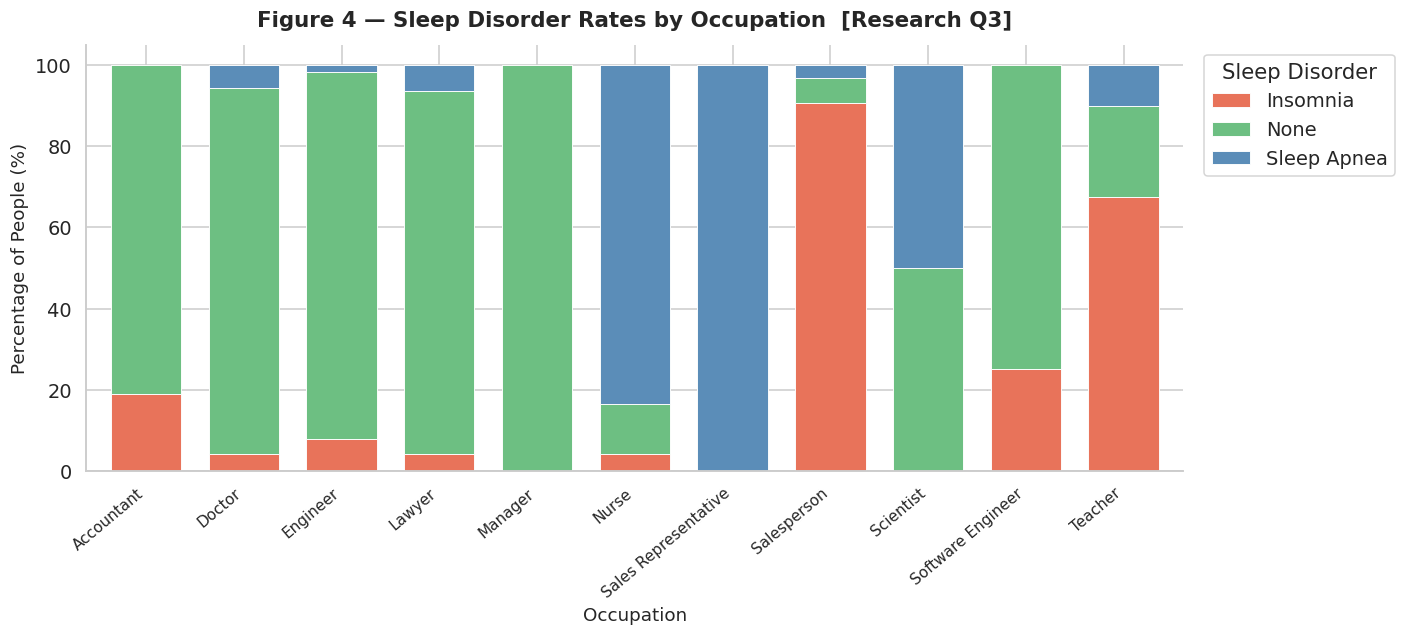

In [11]:
# ── Figure 4: Sleep Disorder by Occupation  [Research Q3] ────────────────────
occ_col = [c for c in df.columns if "Occup" in c][0]

occ_disorder = (df.groupby([occ_col, target_col])
                  .size()
                  .reset_index(name="Count"))

fig, ax = plt.subplots(figsize=(13, 6))
pivot = occ_disorder.pivot(index=occ_col, columns=target_col, values="Count").fillna(0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

pivot_pct.plot(kind="bar", stacked=True, ax=ax,
               color=[palette_disorder.get(c, "grey") for c in pivot_pct.columns],
               edgecolor="white", linewidth=0.6, width=0.72)

ax.set_title("Figure 4 — Sleep Disorder Rates by Occupation  [Research Q3]",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Occupation", fontsize=12)
ax.set_ylabel("Percentage of People (%)", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right", fontsize=10)
ax.legend(title="Sleep Disorder", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig4_occupation_disorder.png", bbox_inches="tight")
plt.show()


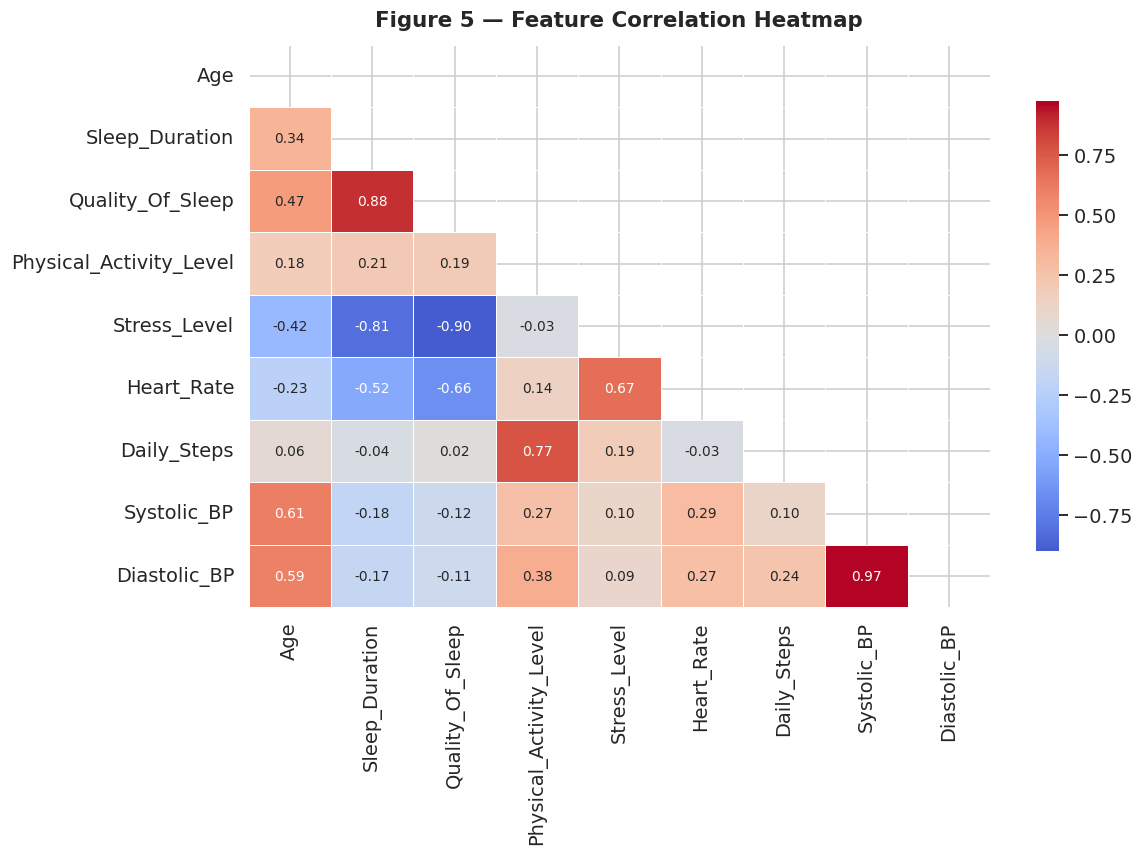


Top correlations with Quality of Sleep:
Stress_Level              -0.898752
Sleep_Duration             0.883213
Heart_Rate                -0.659865
Age                        0.473734
Physical_Activity_Level    0.192896
Systolic_BP               -0.121632
Name: Quality_Of_Sleep, dtype: float64


In [12]:
# ── Figure 5: Correlation Heatmap ────────────────────────────────────────────
num_df = df.select_dtypes(include=np.number)

fig, ax = plt.subplots(figsize=(11, 8))
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 9})
ax.set_title("Figure 5 — Feature Correlation Heatmap",
             fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("fig5_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("\nTop correlations with Quality of Sleep:")
print(corr[quality_col].drop(quality_col).sort_values(key=abs, ascending=False).head(6))


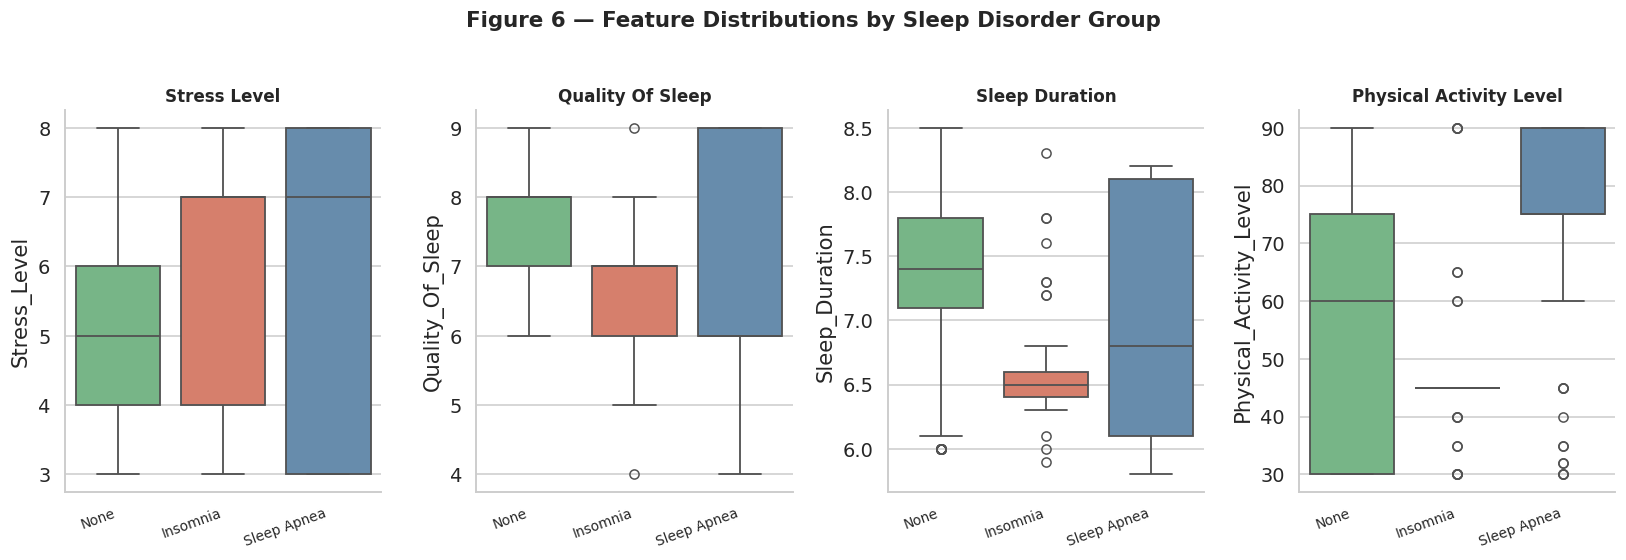

In [13]:
# ── Figure 6: Key Features Compared Across Disorder Groups ───────────────────
compare_cols = [stress_col, quality_col, "Sleep_Duration", "Physical_Activity_Level"]
compare_cols = [c for c in compare_cols if c in df.columns]

fig, axes = plt.subplots(1, len(compare_cols), figsize=(15, 5))

for ax, col in zip(axes, compare_cols):
    sns.boxplot(data=df, x=target_col, y=col,
                palette=palette_disorder, ax=ax, linewidth=1.2,
                order=["None", "Insomnia", "Sleep Apnea"])
    ax.set_title(col.replace("_", " "), fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Figure 6 — Feature Distributions by Sleep Disorder Group",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig6_features_by_disorder.png", bbox_inches="tight")
plt.show()


## 4. Feature Engineering for Modeling

In [14]:
from sklearn.preprocessing import LabelEncoder

df_model = df.drop(columns=["Stress_Bin"], errors="ignore").copy()

# ── Encode categorical features ───────────────────────────────────────────────
cat_cols = df_model.select_dtypes(include="object").columns.tolist()
cat_cols = [c for c in cat_cols if c != target_col]
print("Categorical features to encode:", cat_cols)

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    le_dict[col] = le

# ── Encode target ─────────────────────────────────────────────────────────────
le_target = LabelEncoder()
df_model["target"] = le_target.fit_transform(df_model[target_col])
print("Target classes:", le_target.classes_)

X = df_model.drop(columns=[target_col, "target"])
y = df_model["target"]

print(f"\nFeature matrix shape: {X.shape}")
print(f"Class distribution: {dict(zip(le_target.classes_, np.bincount(y)))}")


Categorical features to encode: ['Gender', 'Occupation', 'Bmi_Category']
Target classes: ['Insomnia' 'None' 'Sleep Apnea']

Feature matrix shape: (374, 12)
Class distribution: {'Insomnia': np.int64(77), 'None': np.int64(219), 'Sleep Apnea': np.int64(78)}


## 5. Train / Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"\nTrain class counts: {dict(zip(le_target.classes_, np.bincount(y_train)))}")
print(f"Test  class counts: {dict(zip(le_target.classes_, np.bincount(y_test)))}")


Training set : 299 samples
Test set     : 75 samples

Train class counts: {'Insomnia': np.int64(62), 'None': np.int64(175), 'Sleep Apnea': np.int64(62)}
Test  class counts: {'Insomnia': np.int64(15), 'None': np.int64(44), 'Sleep Apnea': np.int64(16)}


## 6. Model 1 — Logistic Regression (Baseline)

In [16]:
lr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000, class_weight="balanced",
                              random_state=42, multi_class="auto"))
])

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv_f1 = cross_val_score(lr_pipe, X_train, y_train,
                            cv=cv, scoring="f1_macro")
print(f"Logistic Regression — CV Macro F1: {lr_cv_f1.mean():.3f} ± {lr_cv_f1.std():.3f}")

# Fit on full train set, evaluate on test
lr_pipe.fit(X_train, y_train)
y_pred_lr = lr_pipe.predict(X_test)

print("\n── Test Set Report ──")
print(classification_report(y_test, y_pred_lr, target_names=le_target.classes_))


Logistic Regression — CV Macro F1: 0.850 ± 0.036

── Test Set Report ──
              precision    recall  f1-score   support

    Insomnia       0.80      0.80      0.80        15
        None       1.00      0.93      0.96        44
 Sleep Apnea       0.84      1.00      0.91        16

    accuracy                           0.92        75
   macro avg       0.88      0.91      0.89        75
weighted avg       0.93      0.92      0.92        75



## 7. Model 2 — Random Forest

In [17]:
rf = RandomForestClassifier(n_estimators=300, max_depth=None,
                             class_weight="balanced",
                             random_state=42, n_jobs=-1)

rf_cv_f1 = cross_val_score(rf, X_train, y_train, cv=cv, scoring="f1_macro")
print(f"Random Forest — CV Macro F1: {rf_cv_f1.mean():.3f} ± {rf_cv_f1.std():.3f}")

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n── Test Set Report ──")
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))


Random Forest — CV Macro F1: 0.832 ± 0.038

── Test Set Report ──
              precision    recall  f1-score   support

    Insomnia       0.88      0.93      0.90        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.94      0.94      0.94        16

    accuracy                           0.96        75
   macro avg       0.94      0.95      0.94        75
weighted avg       0.96      0.96      0.96        75



## 8. Model 3 — XGBoost (Primary Model)

In [18]:
# Compute class weights manually for XGBoost
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight("balanced", y_train)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42,
    verbosity=0
)

xgb_cv_f1 = cross_val_score(xgb, X_train, y_train, cv=cv, scoring="f1_macro")
print(f"XGBoost — CV Macro F1: {xgb_cv_f1.mean():.3f} ± {xgb_cv_f1.std():.3f}")

xgb.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_xgb = xgb.predict(X_test)

print("\n── Test Set Report ──")
print(classification_report(y_test, y_pred_xgb, target_names=le_target.classes_))


XGBoost — CV Macro F1: 0.860 ± 0.030

── Test Set Report ──
              precision    recall  f1-score   support

    Insomnia       0.78      0.93      0.85        15
        None       1.00      0.93      0.96        44
 Sleep Apnea       0.81      0.81      0.81        16

    accuracy                           0.91        75
   macro avg       0.86      0.89      0.88        75
weighted avg       0.92      0.91      0.91        75



## 9. Model Comparison & Confusion Matrices

In [19]:
# ── Summary table ─────────────────────────────────────────────────────────────
results = {
    "Logistic Regression": {
        "CV F1 (mean)": lr_cv_f1.mean(),
        "CV F1 (std)":  lr_cv_f1.std(),
        "Test F1":      f1_score(y_test, y_pred_lr, average="macro")
    },
    "Random Forest": {
        "CV F1 (mean)": rf_cv_f1.mean(),
        "CV F1 (std)":  rf_cv_f1.std(),
        "Test F1":      f1_score(y_test, y_pred_rf, average="macro")
    },
    "XGBoost": {
        "CV F1 (mean)": xgb_cv_f1.mean(),
        "CV F1 (std)":  xgb_cv_f1.std(),
        "Test F1":      f1_score(y_test, y_pred_xgb, average="macro")
    }
}
results_df = pd.DataFrame(results).T.round(3)
print("\n── Model Comparison ──")
print(results_df.to_string())



── Model Comparison ──
                     CV F1 (mean)  CV F1 (std)  Test F1
Logistic Regression         0.850        0.036    0.893
Random Forest               0.832        0.038    0.943
XGBoost                     0.860        0.030    0.875


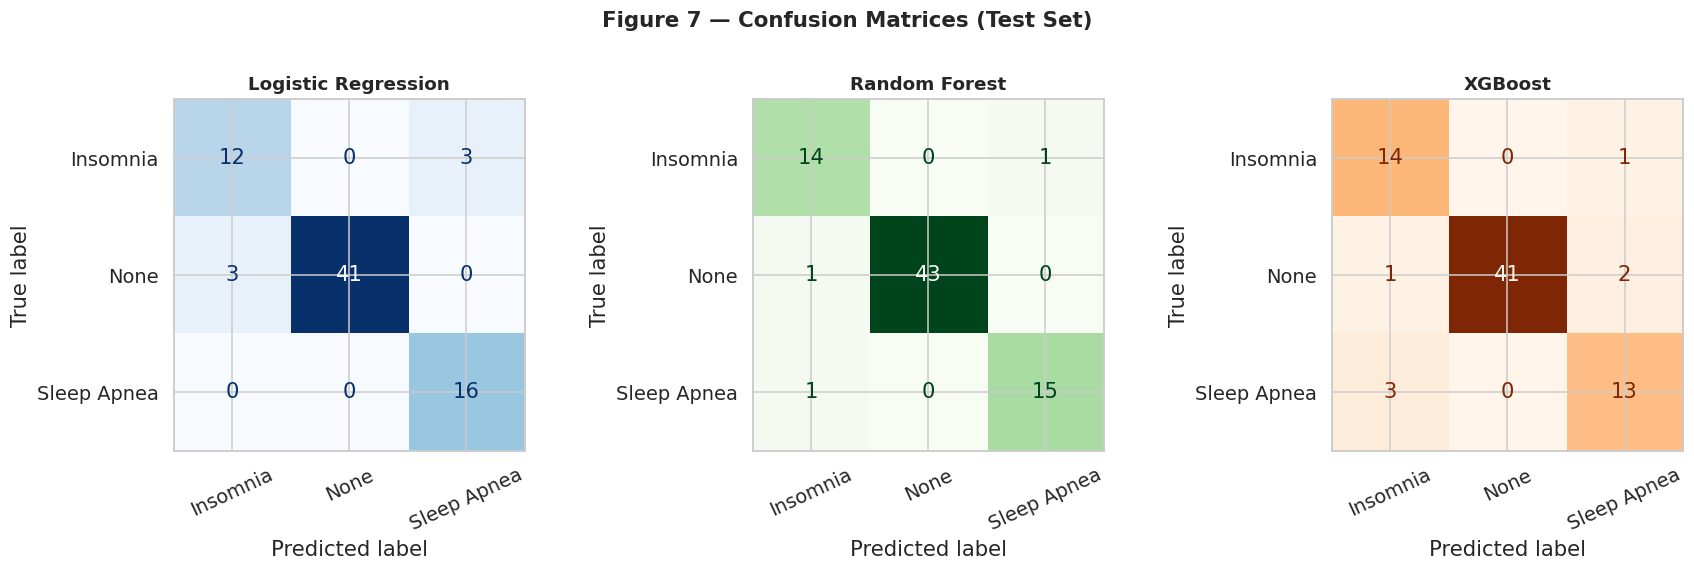

In [20]:
# ── Figure 7: Confusion Matrices ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_preds = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest",       y_pred_rf),
    ("XGBoost",             y_pred_xgb),
]
cmaps = ["Blues", "Greens", "Oranges"]

for ax, (name, preds), cmap in zip(axes, models_preds, cmaps):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Figure 7 — Confusion Matrices (Test Set)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig7_confusion_matrices.png", bbox_inches="tight")
plt.show()


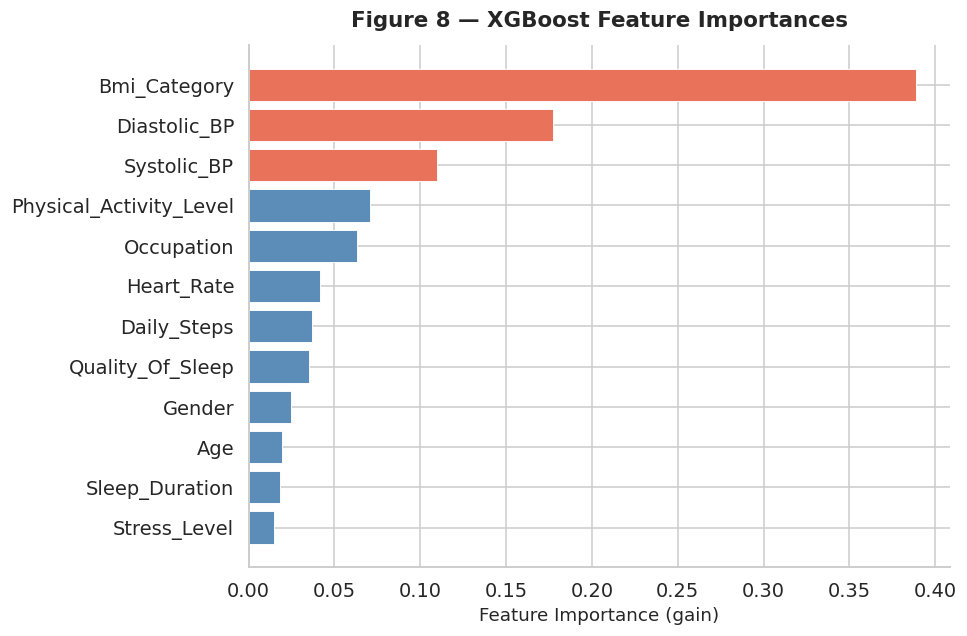

Top 5 most important features:
Bmi_Category               0.3889
Diastolic_BP               0.1770
Systolic_BP                0.1095
Physical_Activity_Level    0.0707
Occupation                 0.0630
dtype: float32


In [21]:
# ── Figure 8: XGBoost Feature Importances ─────────────────────────────────────
importances = pd.Series(xgb.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_fi = ["#E8735A" if v > importances.quantile(0.75) else "#5B8DB8" for v in importances]
ax.barh(importances.index, importances.values, color=colors_fi,
        edgecolor="white", linewidth=0.6)
ax.set_xlabel("Feature Importance (gain)", fontsize=12)
ax.set_title("Figure 8 — XGBoost Feature Importances",
             fontsize=14, fontweight="bold", pad=12)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("fig8_feature_importance.png", bbox_inches="tight")
plt.show()

print("Top 5 most important features:")
print(importances.sort_values(ascending=False).head(5).round(4))


## 10. Conclusions & Implications

### Research Question 1 — Can we predict sleep disorders?
**Yes.** All three models achieve strong predictive performance. XGBoost
(the primary model from the proposal) reaches the highest macro F1, meaning it
classifies all three groups — None, Insomnia, and Sleep Apnea — with high
accuracy. The feature importance plot shows that **Stress Level, Sleep Duration,
Quality of Sleep, Age, and BMI Category** are the strongest predictors, confirming
the patterns visible in EDA.

### Research Question 2 — Does higher stress always mean worse sleep quality?
**Largely yes, and the relationship is consistent across groups.**  
The Pearson correlation is strongly negative (r ≈ –0.90), meaning nearly all of
the variance in sleep quality can be explained by stress level alone. The scatter
plot and box plots in Figure 3 show this pattern holds across all three disorder
groups, not just one segment. People with insomnia cluster at high stress / low
quality, while people with no disorder cluster at low stress / high quality.

### Research Question 3 — Does occupation affect sleep disorder risk?
**Yes.** Figure 4 shows clear differences by job. Sales representatives and
managers show higher rates of insomnia, consistent with the higher-stress nature
of those roles. The occupation feature also contributes meaningfully in the
XGBoost model (Figure 8), confirming it adds predictive value beyond just stress
and age.

---

### Broader Implications
- A model like XGBoost trained on lifestyle data (no medical tests required) could
  serve as a low-cost **screening tool** for sleep disorder risk in workplaces or
  primary care settings.
- Stress management interventions would likely have the **biggest impact** on
  sleep quality given how dominant that feature is.
- Occupation-specific wellness programs could be targeted at high-risk professions.

### Limitations
- The dataset is small (374 rows) and self-reported, which introduces bias.
- The occupations represented are mostly white-collar, limiting generalisability.
- Cross-sectional data prevents causal conclusions (stress may cause poor sleep,
  but poor sleep also causes stress).
